# Showcasing Pathfinder for the different radar systems

In [44]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Loading all the RADAR objects

In [48]:
path = "../Data/AWI/your_RADAR_object.pkl" #this was created in make_RADAR.ipynb. Pathfinder has been run in ht fig09_Pathfinder_otherRadars.ipynb
RADAR_AWI = load_RADAR(path=path) 

path = "../Data/GEORESEARCH/your_RADAR_object.pkl"
RADAR_GR = load_RADAR(path=path)

path = "../Data/Kiwi/your_RADAR_object.pkl"
RADAR_KIWI = load_RADAR(path=path)


Dataset  from campaign  is loaded from ../Data/AWI/your_RADAR_object.pkl
Dataset  from campaign  is loaded from ../Data/GEORESEARCH/your_RADAR_object.pkl
Dataset  from campaign  is loaded from ../Data/Kiwi/your_RADAR_object.pkl


In [60]:
RADAR_GR.distance

AttributeError: 'rdr' object has no attribute 'distance'

array([-0.4  , -0.385, -0.37 , -0.355, -0.34 , -0.325, -0.31 , -0.295,
       -0.28 , -0.265, -0.25 , -0.235, -0.22 , -0.205, -0.19 , -0.175,
       -0.16 , -0.145, -0.13 , -0.115, -0.1  , -0.085, -0.07 , -0.055,
       -0.04 , -0.025, -0.01 ,  0.005,  0.02 ,  0.035,  0.05 ,  0.065,
        0.08 ,  0.095,  0.11 ,  0.125,  0.14 ,  0.155,  0.17 ,  0.185,
        0.2  ,  0.215,  0.23 ,  0.245,  0.26 ,  0.275,  0.29 ,  0.305,
        0.32 ,  0.335,  0.35 ,  0.365,  0.38 ,  0.395,  0.41 ,  0.425,
        0.44 ,  0.455,  0.47 ,  0.485,  0.5  ,  0.515,  0.53 ,  0.545,
        0.56 ,  0.575,  0.59 ,  0.605,  0.62 ,  0.635,  0.65 ,  0.665,
        0.68 ,  0.695,  0.71 ,  0.725,  0.74 ,  0.755,  0.77 ,  0.785,
        0.8  ,  0.815,  0.83 ,  0.845,  0.86 ,  0.875,  0.89 ,  0.905,
        0.92 ,  0.935,  0.95 ,  0.965,  0.98 ,  0.995,  1.01 ,  1.025,
        1.04 ,  1.055,  1.07 ,  1.085,  1.1  ,  1.115,  1.13 ,  1.145,
        1.16 ,  1.175,  1.19 ,  1.205,  1.22 ,  1.235,  1.25 ,  1.265,
      

Text(0.01, 0.97, '(c)')

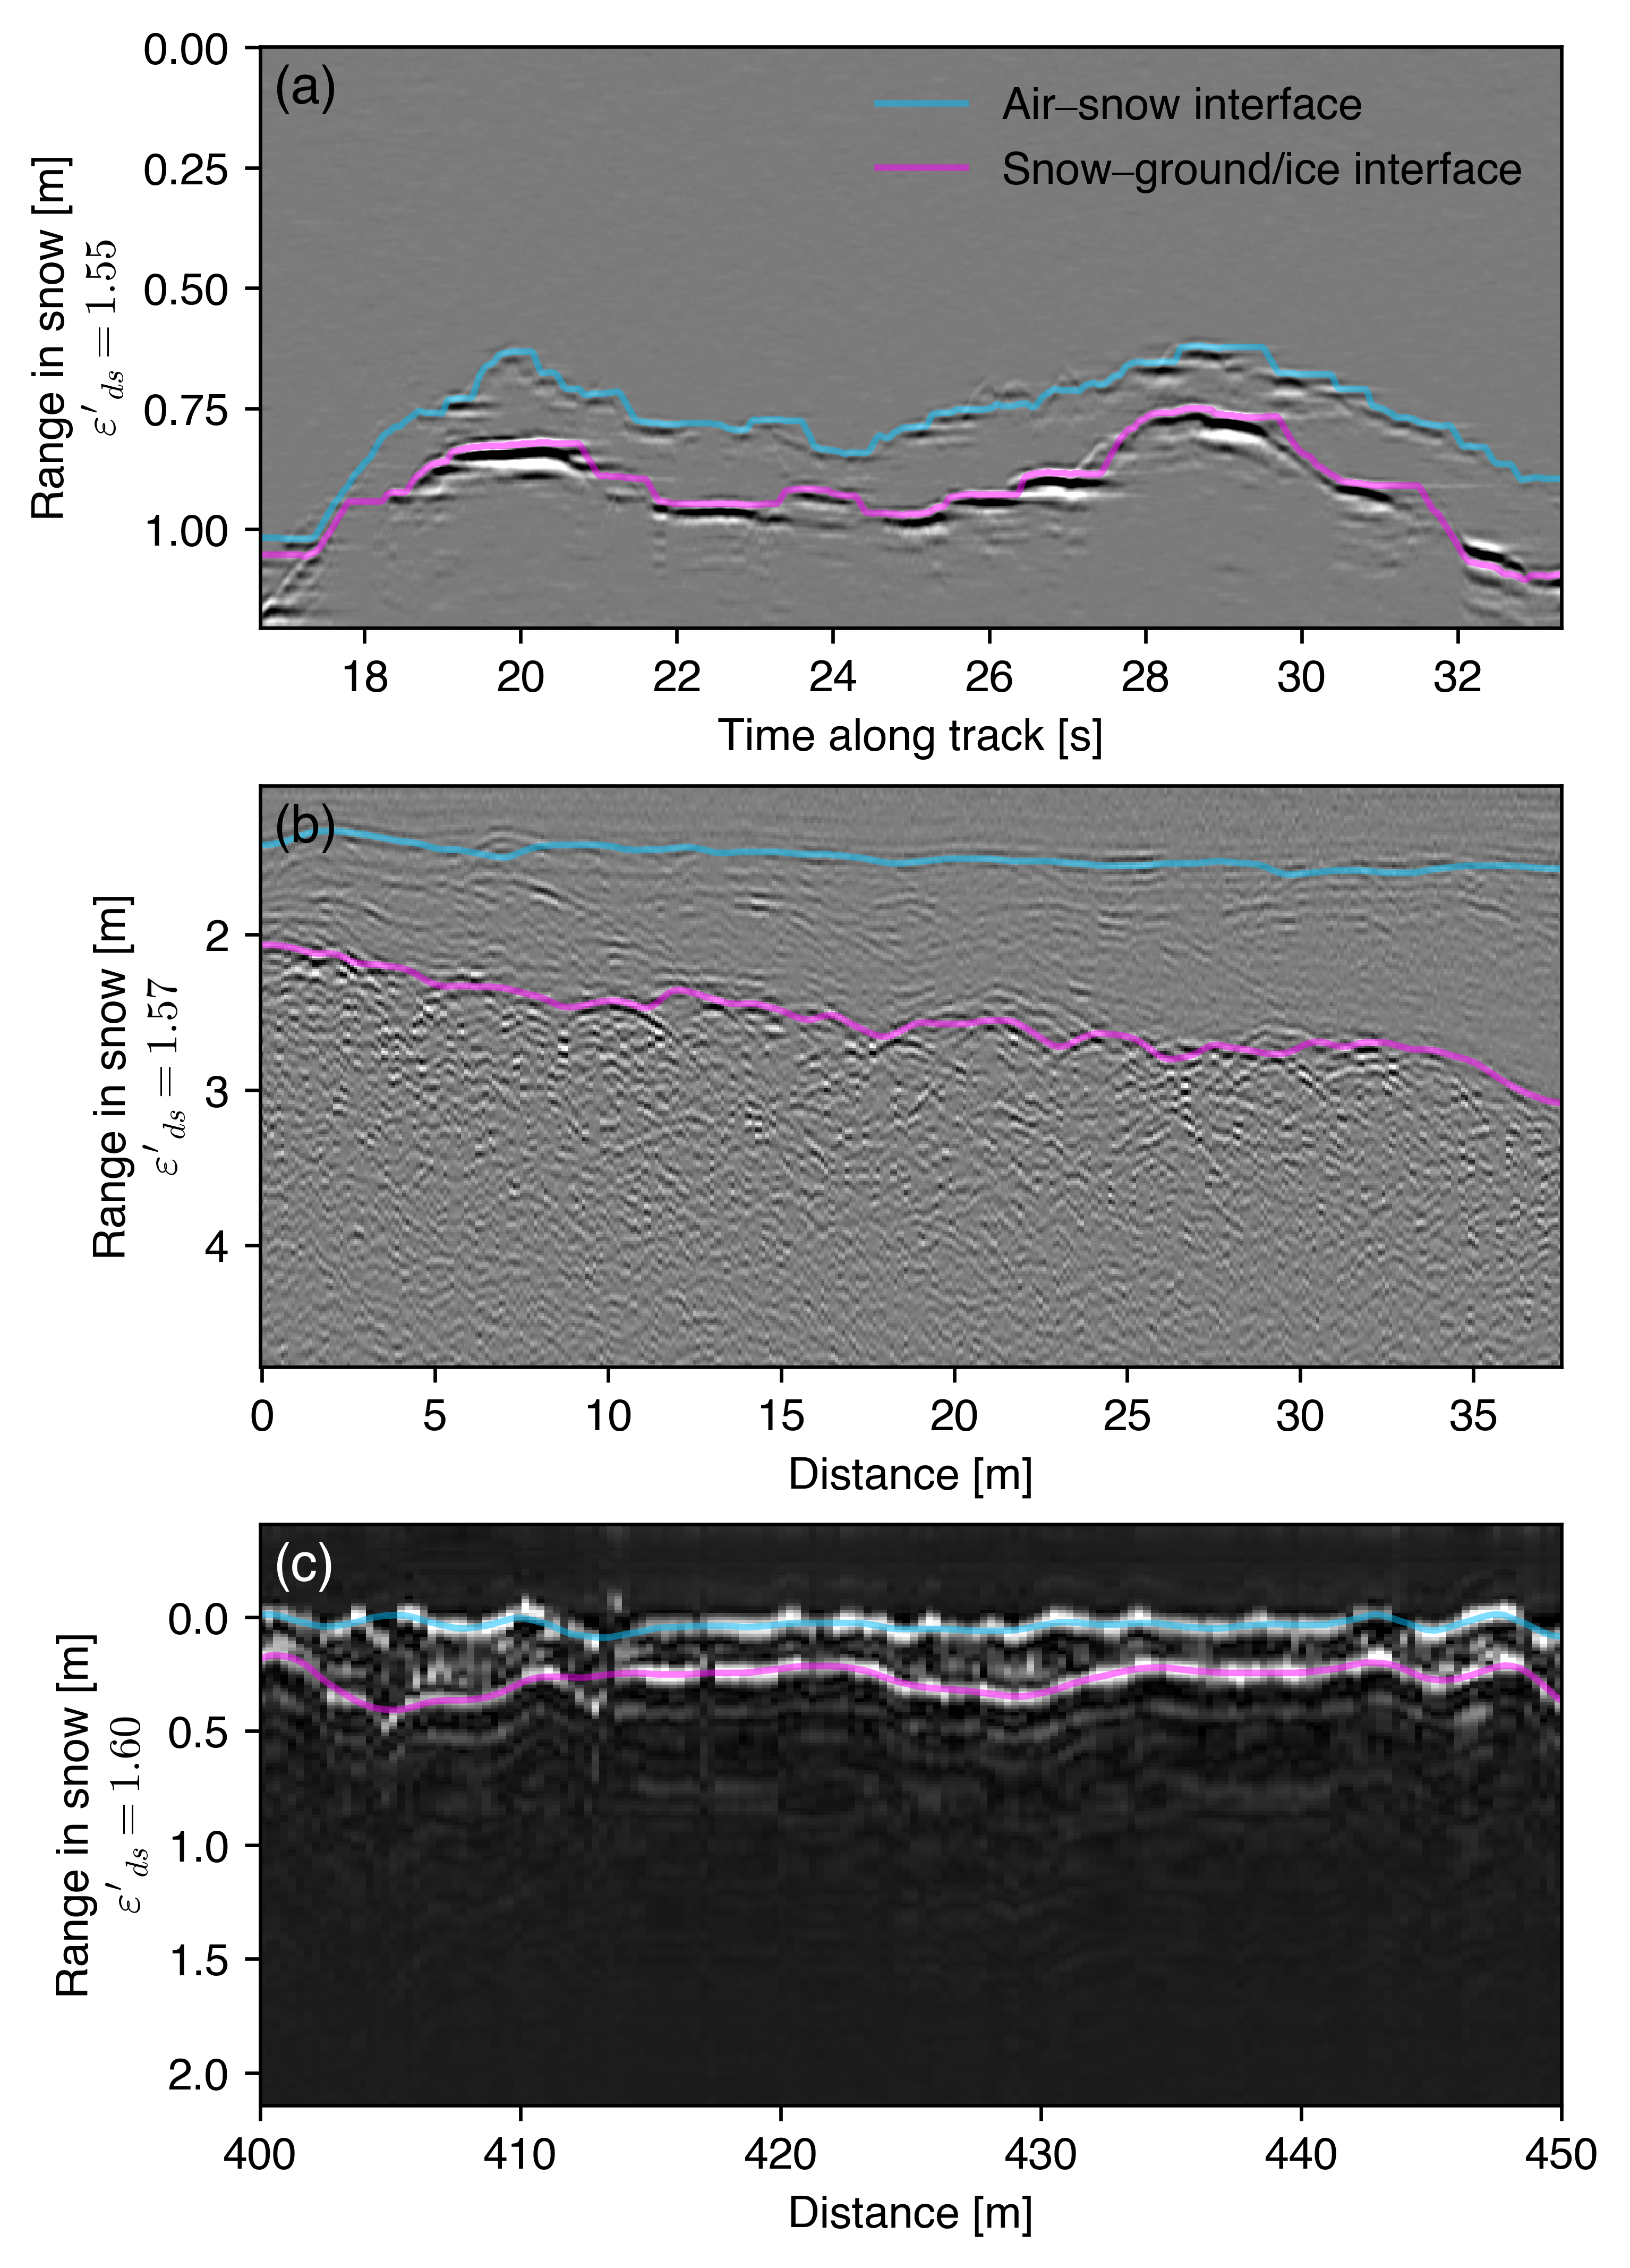

In [109]:
fig, ax = plt.subplots(3,1, figsize=(5,7), constrained_layout=True, dpi=600)

#AWI
ax[0].pcolormesh(RADAR_AWI.slowtime[2000:4000], RADAR_AWI.range_snow, RADAR_AWI.rx_rpca, cmap='gray',
                 vmin=np.nanquantile(RADAR_AWI.rx_rpca, 0.005), vmax=np.nanquantile(RADAR_AWI.rx_rpca, 0.995)
                 )
ax[0].plot(RADAR_AWI.slowtime[2000:4000], pd.Series([RADAR_AWI.range_snow[i] for i in RADAR_AWI.PF_top_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='deepskyblue',
           linewidth=1.5,
           alpha=.5,
           label='Air$\\endash$snow interface'
           )
ax[0].plot(RADAR_AWI.slowtime[2000:4000], pd.Series([RADAR_AWI.range_snow[i] for i in RADAR_AWI.PF_bottom_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='magenta',
           linewidth=1.5,
           alpha=.5,
           label='Snow$\\endash$ground/ice interface'
           )
ax[0].set_ylabel("Range in snow [m]\n$\\varepsilon'_{ds} = 1.55$")
ax[0].set_xlabel("Time along track [s]")
ax[0].invert_yaxis()
ax[0].legend(loc='upper right', frameon=False)

#GEORESEARCH
ax[1].pcolormesh(np.arange(0, len(RADAR_GR.PF_bottom_interface) * 0.1, 0.1), RADAR_GR.range_snow, Quickboost(RADAR_GR.rx_rpca,0.05), cmap='gray',)
ax[1].plot(np.arange(0, len(RADAR_GR.PF_bottom_interface) * 0.1, 0.1), pd.Series([RADAR_GR.range_snow[i] for i in RADAR_GR.PF_top_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='deepskyblue',
           linewidth=1.5,
           alpha=.5
           )
ax[1].plot(np.arange(0, len(RADAR_GR.PF_bottom_interface) * 0.1, 0.1), pd.Series([RADAR_GR.range_snow[i] for i in RADAR_GR.PF_bottom_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='magenta',
           linewidth=1.5,
           alpha=.5
           )
ax[1].invert_yaxis()
ax[1].set_ylabel("Range in snow [m]\n$\\varepsilon'_{ds} = 1.57$")
ax[1].set_xlabel("Distance [m]")

#KIWI
ax[2].pcolormesh(RADAR_KIWI.dist, RADAR_KIWI.range_air, RADAR_KIWI.rx_rpca, cmap='gray',
                 vmin=np.nanquantile(RADAR_KIWI.rx_rpca, 0.005), vmax=np.nanquantile(RADAR_KIWI.rx_rpca, 0.995)
                 )
ax[2].plot(RADAR_KIWI.dist, pd.Series([RADAR_KIWI.range_air[i] for i in RADAR_KIWI.PF_top_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='deepskyblue',
           linewidth=1.5,
           alpha=.5
           )
ax[2].plot(RADAR_KIWI.dist, pd.Series([RADAR_KIWI.range_air[i] for i in RADAR_KIWI.PF_bottom_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='magenta',
           linewidth=1.5,
           alpha=.5
           )
ax[2].invert_yaxis()
ax[2].set_ylabel("Range in snow [m]\n$\\varepsilon'_{ds} = 1.60$")
ax[2].set_xlabel("Distance [m]")
ax[2].set_xlim(400, 450)


ax[0].text(0.01, 0.97, '(a)', transform=ax[0].transAxes, verticalalignment='top', horizontalalignment='left', fontsize=12)
ax[1].text(0.01, 0.97, '(b)', transform=ax[1].transAxes, verticalalignment='top', horizontalalignment='left', fontsize=12)
ax[2].text(0.01, 0.97, '(c)', transform=ax[2].transAxes, verticalalignment='top', horizontalalignment='left', fontsize=12, color='white')
